In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import yfinance as yf
import scipy.stats as stats

In [2]:
df = pd.read_excel("../financial_data/vinfast_stock_data_7_9_2021_to_21_5_2026.xlsx")

In [3]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,2026-05-12 00:00:00,3.60,3.630,3.545,3.610,3.610,451000
1,2026-05-20 00:00:00,3.56,3.669,3.540,3.600,3.600,366400
2,2026-05-19 00:00:00,3.65,3.675,3.510,3.530,3.530,583900
3,2026-05-18 00:00:00,3.83,3.865,3.670,3.670,3.670,584000
4,2026-05-15 00:00:00,3.82,3.940,3.761,3.830,3.830,568100
...,...,...,...,...,...,...,...
1177,13 Sept 2021,9.71,9.710,9.710,9.710,9.710,400
1178,10 Sept 2021,9.69,9.690,9.680,9.680,9.680,700
1179,9 Sept 2021,9.61,9.691,9.610,9.682,9.682,400
1180,8 Sept 2021,9.71,9.710,9.710,9.710,9.710,3700


In [4]:
df.columns = ['date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume']

df['date'] = pd.to_datetime(df['date'], format='mixed')

In [5]:
df

,date,open,high,low,close,adjusted_close,volume
0,2026-05-12,3.60,3.630,3.545,3.610,3.610,451000
1,2026-05-20,3.56,3.669,3.540,3.600,3.600,366400
2,2026-05-19,3.65,3.675,3.510,3.530,3.530,583900
3,2026-05-18,3.83,3.865,3.670,3.670,3.670,584000
4,2026-05-15,3.82,3.940,3.761,3.830,3.830,568100
...,...,...,...,...,...,...,...
1177,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
1178,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1179,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1180,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700


In [6]:
df.isna().sum()

date              0
open              0
high              0
low               0
close             0
adjusted_close    0
volume            0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df['date'] = pd.to_datetime(df['date'], format="mixed")


In [9]:
df = df.sort_values(['date'],ascending=True) 
df


,date,open,high,low,close,adjusted_close,volume
1181,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1180,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
1179,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1178,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1177,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
5,2026-05-14,4.01,4.045,3.782,3.890,3.890,763500
4,2026-05-15,3.82,3.940,3.761,3.830,3.830,568100
3,2026-05-18,3.83,3.865,3.670,3.670,3.670,584000
2,2026-05-19,3.65,3.675,3.510,3.530,3.530,583900


In [10]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close
open,1.000000,0.977843,0.982020,0.966889,0.966889
high,0.977843,1.000000,0.964378,0.985623,0.985623
low,0.982020,0.964378,1.000000,0.982231,0.982231
close,0.966889,0.985623,0.982231,1.000000,1.000000
adjusted_close,0.966889,0.985623,0.982231,1.000000,1.000000


In [11]:
plt.style.use("bmh")

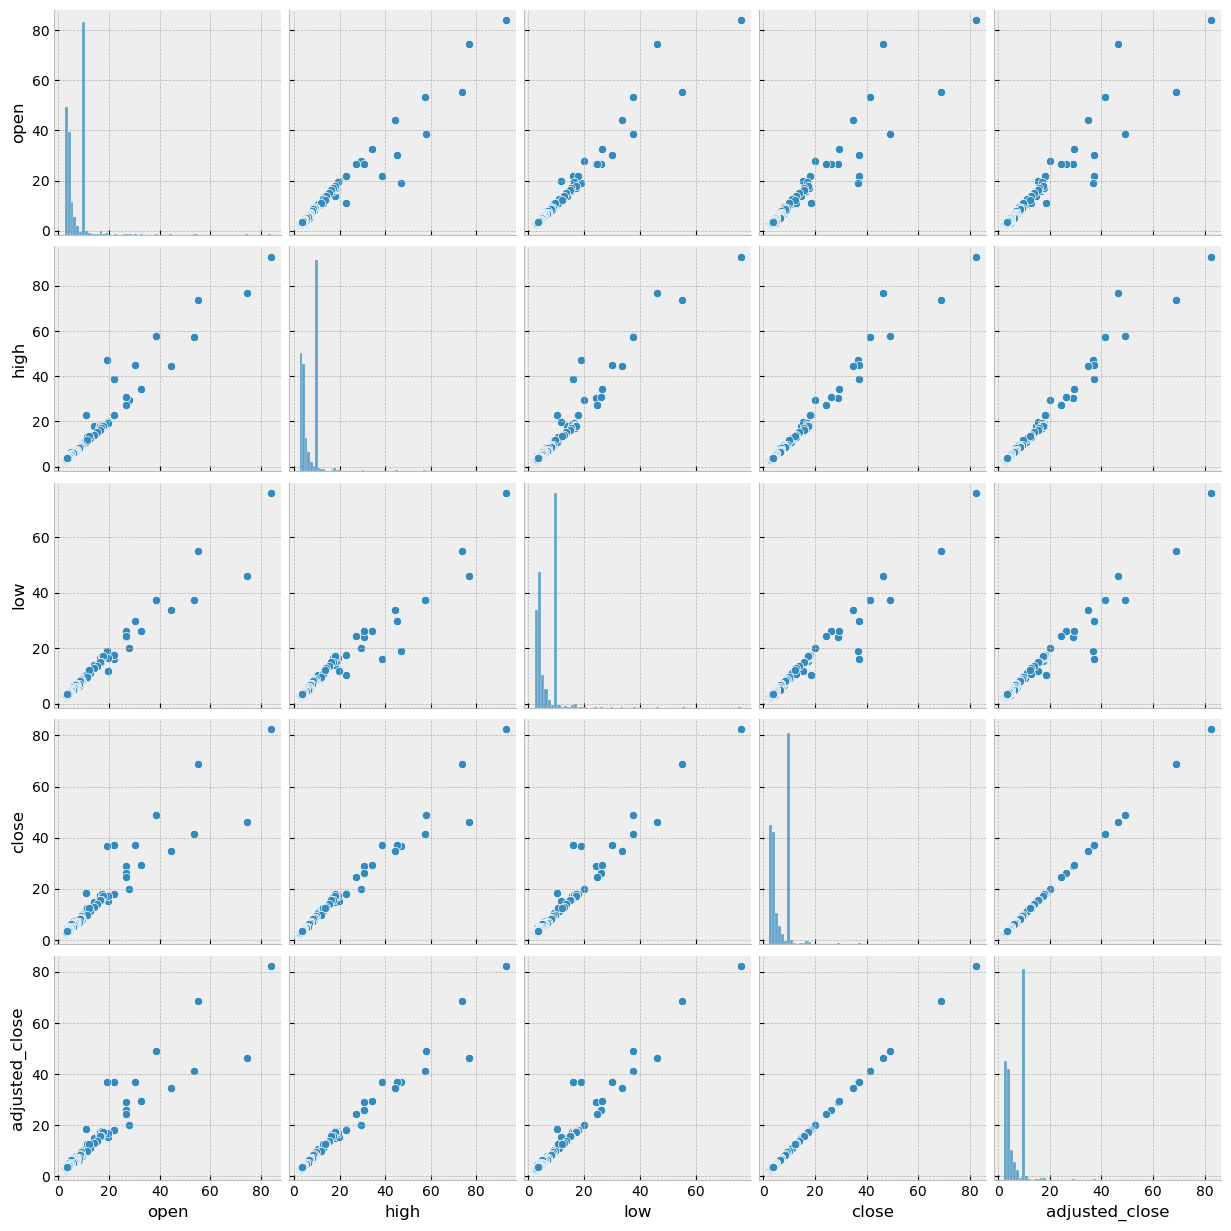

In [12]:
sns.pairplot(df)

In [13]:
df.index = df.date 
df.drop(['date'],axis=1,inplace=True) 


In [14]:
df

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...
2026-05-14,4.01,4.045,3.782,3.890,3.890,763500
2026-05-15,3.82,3.940,3.761,3.830,3.830,568100
2026-05-18,3.83,3.865,3.670,3.670,3.670,584000


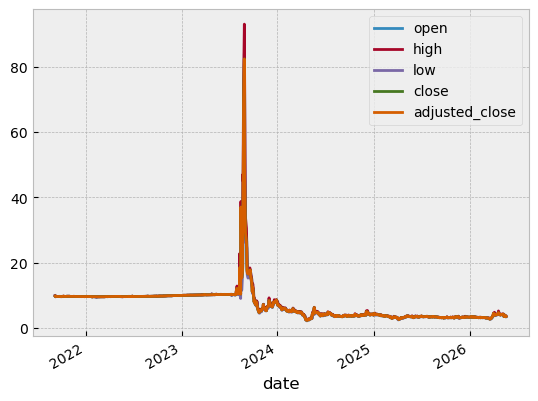

In [15]:
plt.Figure(figsize=(10,10))
df.plot(kind='line')

plt.show()

In [16]:
df.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400


In [17]:
df.reset_index(inplace=True)

In [18]:
df

,date,open,high,low,close,adjusted_close,volume
0,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
1177,2026-05-14,4.01,4.045,3.782,3.890,3.890,763500
1178,2026-05-15,3.82,3.940,3.761,3.830,3.830,568100
1179,2026-05-18,3.83,3.865,3.670,3.670,3.670,584000
1180,2026-05-19,3.65,3.675,3.510,3.530,3.530,583900


In [19]:
df = df.sort_values(['date'],ascending=True)

df = df[df.date > '2024-01-01']

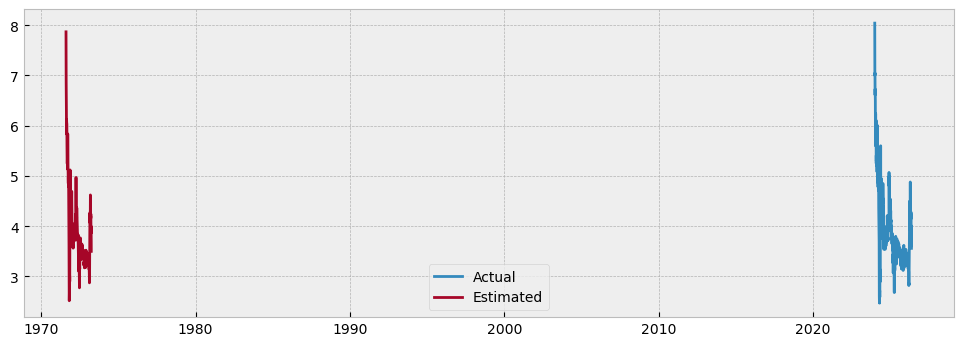

In [20]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open', 'date']])


stl = STL(open_price['open'], period=3) 
result = stl.fit()
seasonal, trend, resid = result.seasonal, result.trend, result.resid 


estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.date, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

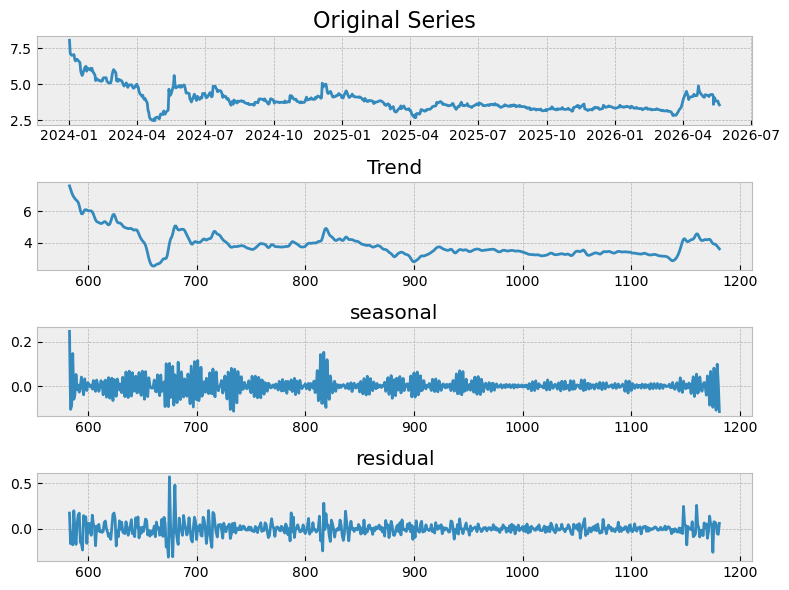

In [21]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(df.date, df['open']) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

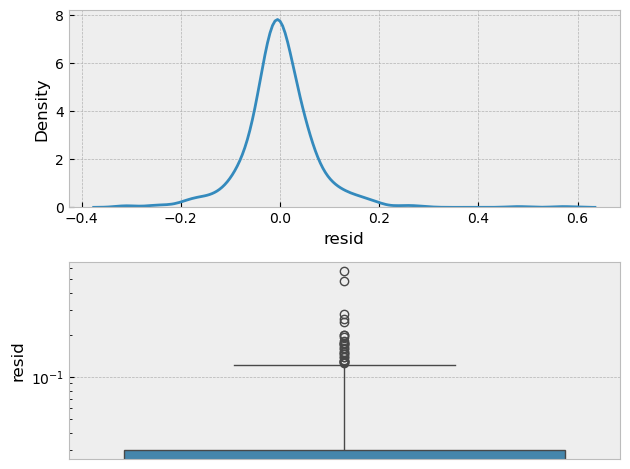

Shapiro -> ShapiroResult(statistic=0.8940757531916808, pvalue=6.89081543727218e-20)


In [22]:
fig, axes=plt.subplots(2) 

sns.kdeplot(resid, ax=axes[0])
sns.boxplot(resid, ax=axes[1])
axes[1].set_yscale("log") 
plt.tight_layout()
plt.show()

import scipy.stats as stats 


print (f"Shapiro -> {stats.shapiro(resid)}")

In [23]:
df

,date,open,high,low,close,adjusted_close,volume
583,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
584,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
585,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
586,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
587,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
1177,2026-05-14,4.010,4.045,3.782,3.89,3.89,763500
1178,2026-05-15,3.820,3.940,3.761,3.83,3.83,568100
1179,2026-05-18,3.830,3.865,3.670,3.67,3.67,584000
1180,2026-05-19,3.650,3.675,3.510,3.53,3.53,583900


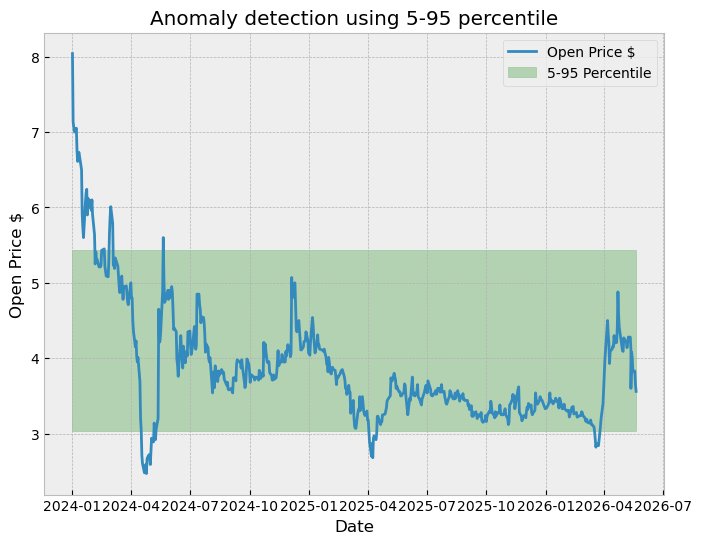

In [24]:
plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = np.percentile(df.open, 95) 
lower = np.percentile(df.open, 5) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 5-95 percentile") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '5-95 Percentile'])
plt.show()

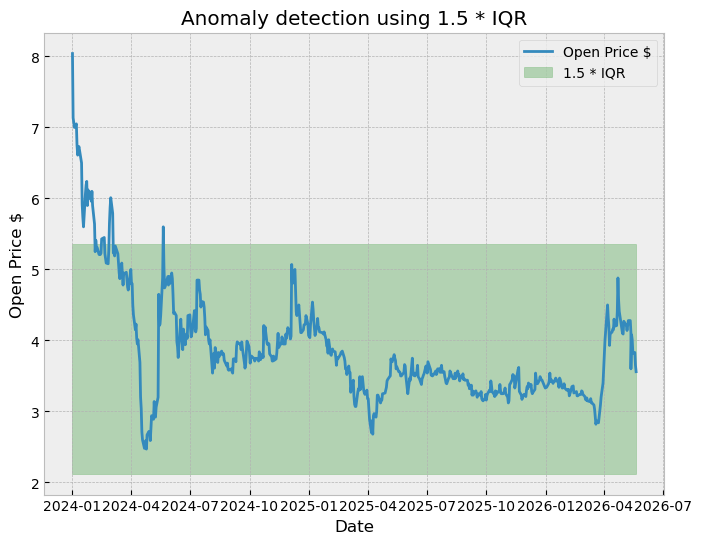

In [25]:
# using IQR

iqr = stats.iqr(df['open']) 




plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = (1.5 * iqr) + np.percentile(df.open, 75)
lower = np.percentile(df.open, 25) - (1.5 * iqr)

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 1.5 * IQR") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '1.5 * IQR'])
plt.show()

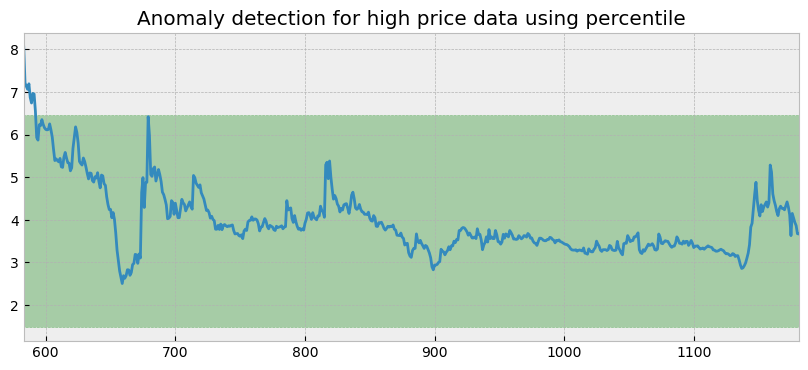

In [26]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['high'].mean() 
open_dev = df['high'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using percentile")
plt.show()

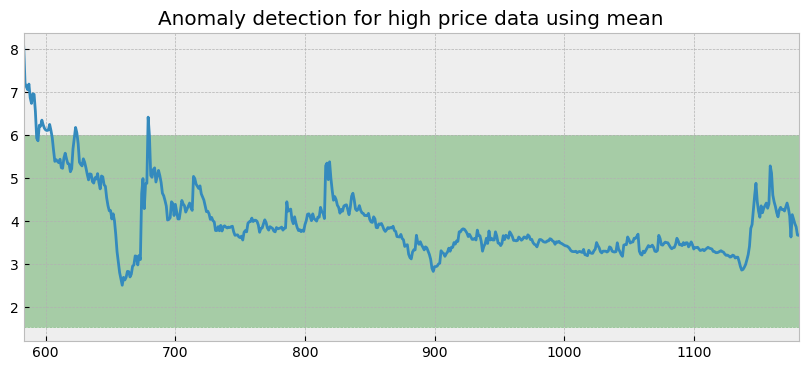

In [27]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['low'].mean() 
open_dev = df['low'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using mean")
plt.show()

In [28]:

df.volume = pd.to_numeric(df.volume)

{'whiskers': [<matplotlib.lines.Line2D at 0x16210e5a0>,
 'caps': [<matplotlib.lines.Line2D at 0x16210eb70>,
 'boxes': [<matplotlib.lines.Line2D at 0x1620faed0>],
 'medians': [<matplotlib.lines.Line2D at 0x16210f170>],
 'fliers': [<matplotlib.lines.Line2D at 0x16210f410>],
 'means': []}

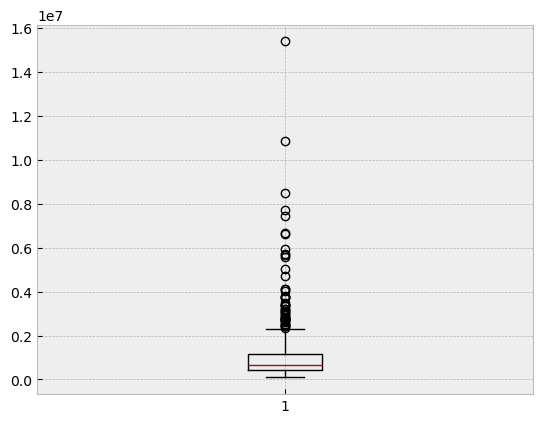

In [29]:
plt.boxplot(df.volume)

In [30]:
min(df.volume)

98200

In [31]:
df.iloc[5]

date              2024-01-09 00:00:00
open                             6.75
high                             6.87
low                              6.41
close                            6.65
adjusted_close                   6.65
volume                        3327700
Name: 588, dtype: object

In [32]:
df.reset_index(inplace=True)

In [33]:
df.head()

,index,date,open,high,low,close,adjusted_close,volume
0,583,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,584,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,585,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,586,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,587,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [34]:
df.drop(['index'],axis=1,inplace=True)

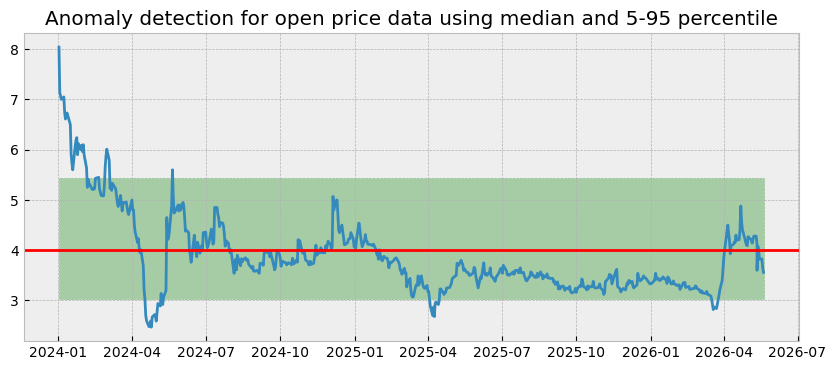

In [35]:


lower=np.percentile(df.open, 5)
upper = np.percentile(df.open, 95) 
plt.figure(figsize=(10,4)) 
plt.plot(df.date, df.open) 
plt.fill_between([min(df.date), max(df.date)], lower, upper, color='g', alpha=0.3, linestyle='--')


plt.axhline(y=4, color='r')
plt.title("Anomaly detection for open price data using median and 5-95 percentile")
plt.show()

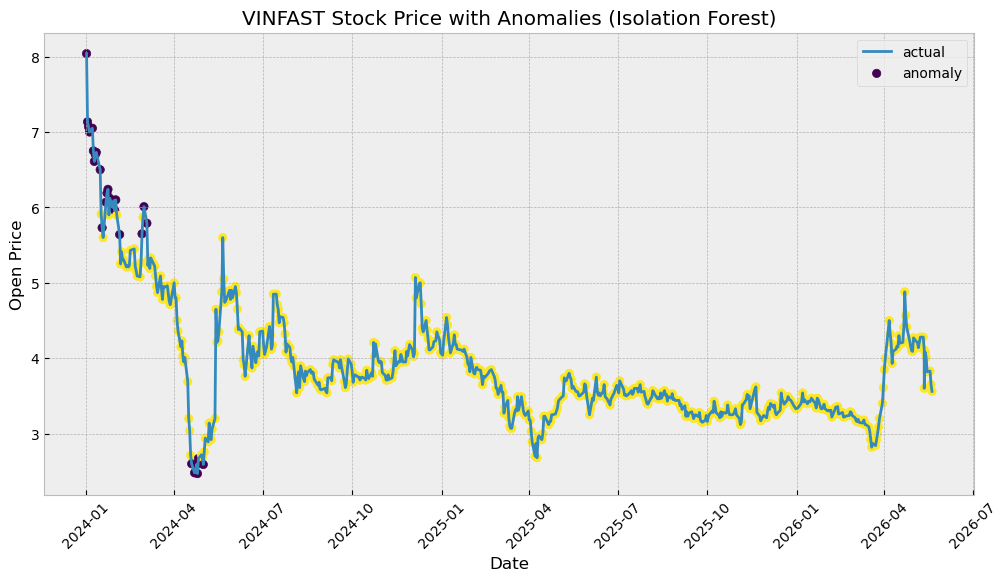

In [36]:
from sklearn.ensemble import IsolationForest

# Prepare the data for Isolation Forest
X = df['open'].values.reshape(-1, 1)

# Train the Isolation Forest model
model = IsolationForest(contamination=0.05)
model.fit(X)

# Predict the anomalies
anomalies = model.predict(X)

# Plot the anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.date, df['open'])
plt.scatter(df.date, df['open'], c=anomalies, label='Anomaly')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('VINFAST Stock Price with Anomalies (Isolation Forest)')
plt.xticks(rotation=45)
plt.legend(['actual', 'anomaly'])
plt.grid(True)

plt.show()

In [37]:
anomalies

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1, -1, -1,  1,
       -1, -1, -1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

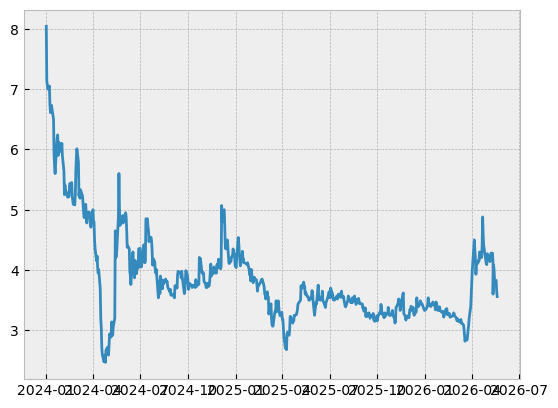

In [38]:
plt.plot(df.date, df.open)

In [39]:
df.head()

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


# Building the model

In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor


## using the cleaning script

In [40]:
import sys 
sys.path.append("../scripts/") 
from clean_time_series import clean_iqr

You have imported the clean_time_series.py module...
This script is based on the idea that you wish to use lagging stock values to predict future stock values
Make sure you have cleaned your data first. This means that:
    1. all columns have been converted to lowercase
    2. all missing/erroenous values have been corrected
-------------------------------
this is the clean_iqr module. This uses the interquartile range to identify anomalies...


In [41]:
df.head()

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [42]:
y = df.open.values.reshape(-1,1) 
np.shape(y)[0]

599

In [43]:
y = np.delete(y, 0)
len(y)

598

In [44]:
len(df)

599

In [67]:
# predicting opening price 


# sorting the data by date

df = df.sort_values(['date'],ascending=True)


X = df.drop(['open', 'close', 'volume'],axis=1) 


y = df.open.values.reshape(-1,1) 
# lagging the y
y_lag = np.delete(y, 0)


train_size=round(len(df) * 0.8)
test_size=round(len(df) * 0.2) 



# creating the train/test split 
X_train = X.head(train_size) 
X_test = X.tail(test_size) 

Y_train = y_lag[0:round(len(y_lag) * 0.8)]
Y_test = y_lag[train_size:np.shape(y)[0]]


# fittign the cleaner
clean_iqr_X = clean_iqr(X_train) 

# creating the column_stats
clean_iqr_X.fit()


X_train_transformed = clean_iqr_X.fit_transform()

X_test_transformed = clean_iqr_X.transform(dataframe=X_test)



Calculating the upper, lower, median and iqr...
Analysing column: high
Analysing column: low
Analysing column: adjusted_close
Using the 1.5 * IQR method for anomaly detection...
Analysing column: high
Analysing column: low
Analysing column: adjusted_close
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
Deleting the unecessary columns...
Columns to remove: ['high', 'low', 'adjusted_close']
Transforming... Dataframe
median: [3.81]
upper: [5.63375]
lower: [2.20375]
Transforming... Dataframe
median: [3.665]
upper: [5.15875]
lower: [2.26875]
Transforming... Dataframe
median: [3.74]
upper: [5.375]
lower: [2.255]


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:168: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [68]:
clean_iqr_X.get_column_stats()

,column,iqr,median,upper,lower
0,high,0.8575,3.810,5.63375,2.20375
1,low,0.7225,3.665,5.15875,2.26875
2,adjusted_close,0.7800,3.740,5.37500,2.25500


In [69]:
X_train_transformed

,day,month,year,high_iqr_imputed,low_iqr_imputed,adjusted_close_iqr_imputed
date,,,,,,
2024-01-02,2,1,2024,3.810,3.665,3.740
2024-01-03,3,1,2024,3.810,3.665,3.740
2024-01-04,4,1,2024,3.810,3.665,3.740
2024-01-05,5,1,2024,3.810,3.665,3.740
2024-01-08,8,1,2024,3.810,3.665,3.740
...,...,...,...,...,...,...
2025-11-20,20,11,2025,3.695,3.450,3.465
2025-11-21,21,11,2025,3.300,3.000,3.230
2025-11-24,24,11,2025,3.230,3.130,3.165


In [70]:
X_test_transformed

,day,month,year,high_iqr_imputed,low_iqr_imputed,adjusted_close_iqr_imputed
date,,,,,,
2025-11-28,28,11,2025,3.264,3.220,3.24
2025-12-01,1,12,2025,3.320,3.210,3.32
2025-12-02,2,12,2025,3.375,3.300,3.35
2025-12-03,3,12,2025,3.430,3.340,3.36
2025-12-04,4,12,2025,3.400,3.320,3.39
...,...,...,...,...,...,...
2026-05-14,14,5,2026,4.045,3.782,3.89
2026-05-15,15,5,2026,3.940,3.761,3.83
2026-05-18,18,5,2026,3.865,3.670,3.67


In [71]:
# building the lagging
X_train_transformed = clean_iqr_X.build_lagging(dataframe=X_train_transformed)
X_test_transformed = clean_iqr_X.build_lagging(dataframe=X_test_transformed)

Created the lagged values...
dataframe:             day  month  year  high_iqr_imputed  low_iqr_imputed  \
date                                                              
2024-01-02    2      1  2024             3.810            3.665   
2024-01-03    3      1  2024             3.810            3.665   
2024-01-04    4      1  2024             3.810            3.665   
2024-01-05    5      1  2024             3.810            3.665   
2024-01-08    8      1  2024             3.810            3.665   
...         ...    ...   ...               ...              ...   
2025-11-20   20     11  2025             3.695            3.450   
2025-11-21   21     11  2025             3.300            3.000   
2025-11-24   24     11  2025             3.230            3.130   
2025-11-25   25     11  2025             3.210            3.070   
2025-11-26   26     11  2025             3.300            3.200   

            adjusted_close_iqr_imputed  lagged_high_iqr_imputed  \
date                 

/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:288: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [72]:
X_train_transformed




,day,month,year,lagged_high_iqr_imputed,lagged_low_iqr_imputed,lagged_adjusted_close_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.810,3.665,3.740
2024-01-04,4,1,2024,3.810,3.665,3.740
2024-01-05,5,1,2024,3.810,3.665,3.740
2024-01-08,8,1,2024,3.810,3.665,3.740
2024-01-09,9,1,2024,3.810,3.665,3.740
...,...,...,...,...,...,...
2025-11-20,20,11,2025,3.640,3.510,3.580
2025-11-21,21,11,2025,3.695,3.450,3.465
2025-11-24,24,11,2025,3.300,3.000,3.230


In [73]:
X_train_transformed.columns

Index(['day', 'month', 'year', 'lagged_high_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='object')

In [74]:
print (np.shape(X_train_transformed)) 
print (np.shape(Y_train)) 
print ("---")
print (np.shape(X_test_transformed)) 
print (np.shape(Y_test))

(478, 6)
(478,)
---
(119, 6)
(119,)


In [75]:
import joblib

In [76]:
model = XGBRegressor()

model.fit(X_train_transformed, Y_train)


pred = model.predict(X_test_transformed)

In [77]:
# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [78]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))


0.08380496573563592
0.050771521400002864
0.9633732413029163


In [79]:
df.tail(test_size).date

479   2025-11-28
480   2025-12-01
481   2025-12-02
482   2025-12-03
483   2025-12-04
         ...    
594   2026-05-14
595   2026-05-15
596   2026-05-18
597   2026-05-19
598   2026-05-20
Name: date, Length: 120, dtype: datetime64[ns]

In [80]:
np.shape(pred)

(119,)

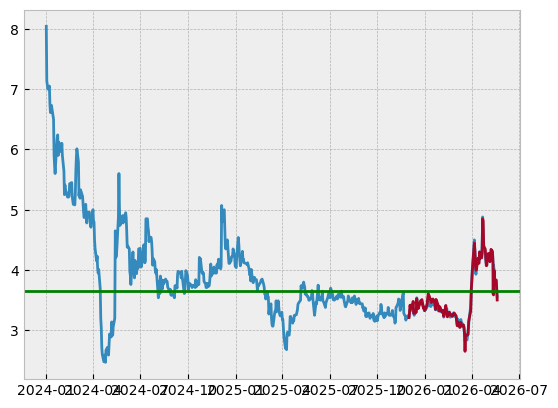

In [81]:
# plotting


plt.plot(df.date, df.open)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.axhline(y=df['open'].median(), color='g')

Text(0.5, 1.0, 'Zoomed in VINFAST opening prices prediction. R2 = 0.963')

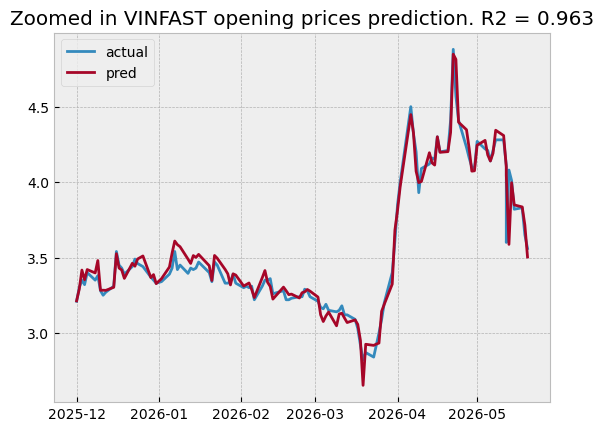

In [82]:
plt.plot(df.tail(test_size).date.iloc[1:], Y_test)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.legend(['actual', 'pred'])

plt.title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")

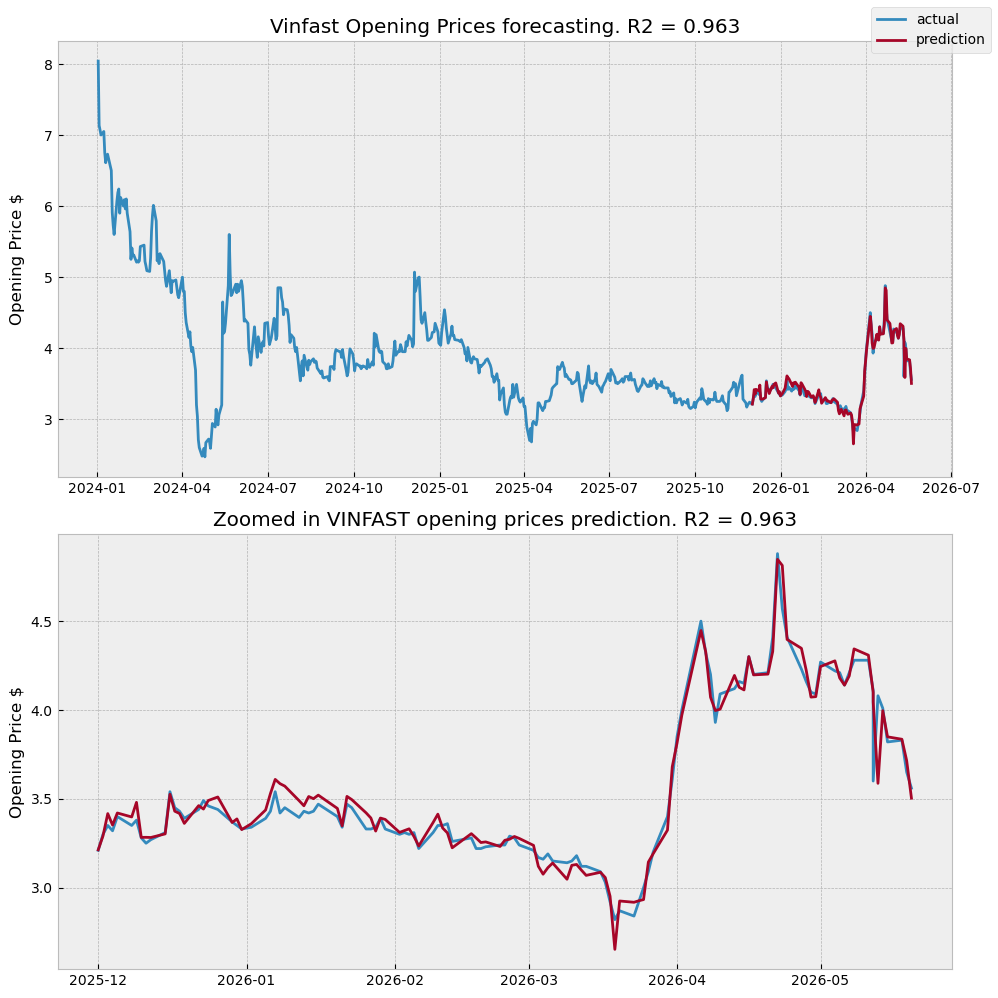

In [83]:
# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.open)
axes[0].plot(df.tail(test_size).date.iloc[1:], pred)



axes[0].set_title(f"Vinfast Opening Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[0].set_ylabel("Opening Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], pred)



axes[1].set_title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[1].set_ylabel("Opening Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Y test')

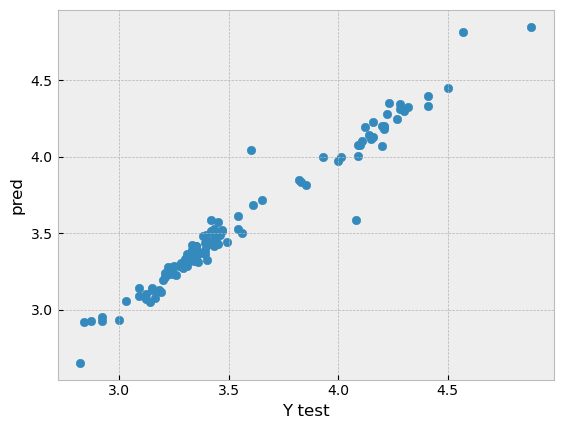

In [84]:
plt.scatter(Y_test, pred) 
plt.ylabel("pred") 
plt.xlabel("Y test")

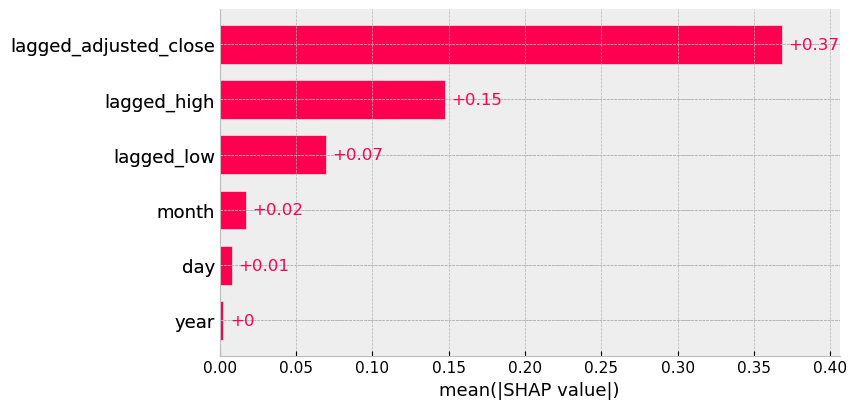

In [69]:
import shap 


explainer = shap.TreeExplainer(model) 
shap_values = explainer(X_test) 


shap.plots.bar(shap_values)

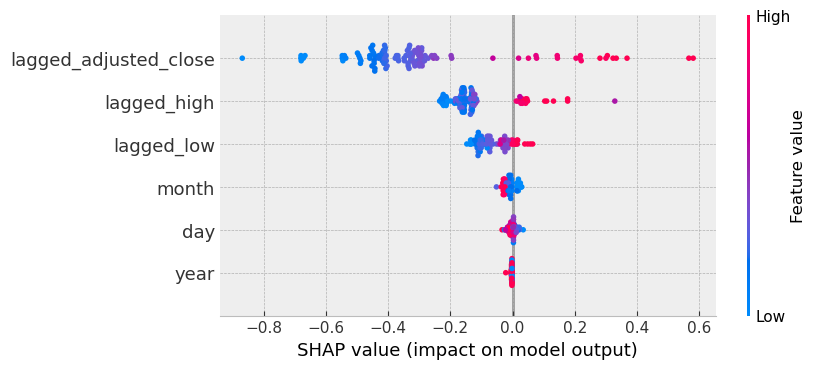

In [248]:
shap.plots.beeswarm(shap_values)

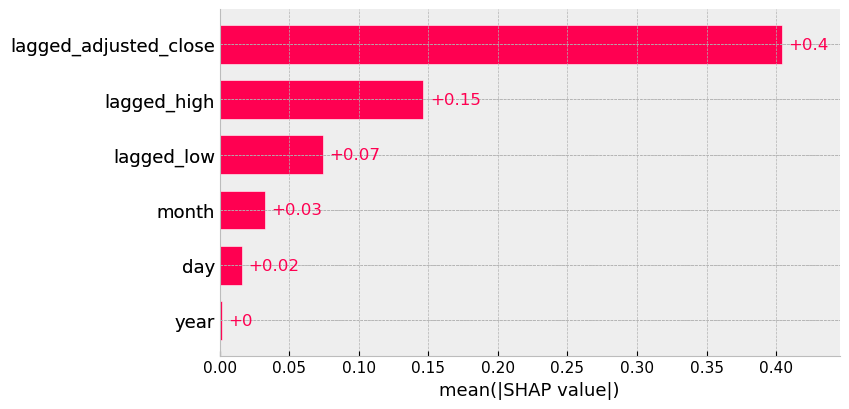

In [249]:



train_shap_values = explainer(X_train) 


shap.plots.bar(train_shap_values)

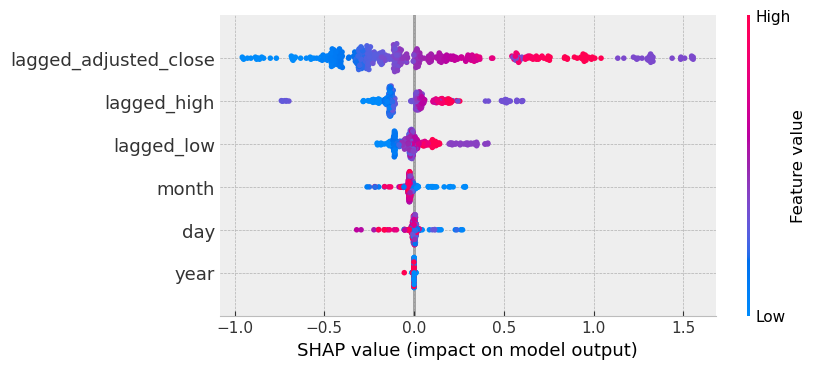

In [250]:



train_shap_values = explainer(X_train) 


shap.plots.beeswarm(train_shap_values)

In [65]:
!pwd

/Users/thomasnguyen/projects/news_project/notebooks


In [254]:
import joblib

In [ ]:
model.fea

In [86]:
import joblib 

joblib.dump(model, "/Users/thomasnguyen/projects/news_project/models/time_series/vinfast/vinfast_open_forecaster.pkl")

['/Users/thomasnguyen/projects/news_project/models/time_series/vinfast/vinfast_open_forecaster.pkl']

In [230]:
import sys 
sys.path.append("../scripts/")
from clean_vinfast_stock import column_cleaner

In [63]:
model.feature_names_in_

array(['day', 'month', 'year', 'lagged_high_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [69]:
test = joblib.load('../models/time_series/vinfast/vinfast_open_forecaster.pkl') 
test.feature_names_in_

array(['day', 'month', 'year', 'lagged_high_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [266]:
print ("Predicting opening price for 5/05/2026")
first_may = pd.DataFrame({
    'day': [5],
    'month': [5],
    'year': [2026],
    'lagged_high_iqr_imputed': [4.27],
    'lagged_low_iqr_imputed': [4.16],
    'lagged_adjusted_close_iqr_imputed': [4.21]
 

    


})

mae = mean_absolute_error(y_true=Y_test, y_pred=pred)

first_may_cleaned = column_cleaner(first_may) 
first_may_cleaned = first_may_cleaned.clean_columns() 

prediction = model.predict(first_may_cleaned) 
print (f"Prediction: {prediction}")
print (f"upper bound: {prediction + mae}")
print (f"lower bound: {prediction - mae}")



Predicting opening price for 5/05/2026
   day  month  year  lagged_high_iqr_imputed  lagged_low_iqr_imputed  \
0    5      5  2026                     4.27                    4.16   

   lagged_adjusted_close_iqr_imputed  
0                               4.21  
Prediction: [4.2061234]
upper bound: [4.259579]
lower bound: [4.1526675]


In [267]:
first_may_cleaned

,day,month,year,lagged_high_iqr_imputed,lagged_low_iqr_imputed,lagged_adjusted_close_iqr_imputed
0,5,5,2026,4.27,4.16,4.21


In [268]:
mae

0.05345583822830863

# Training a "High" forecaster

In [269]:
import sys 
sys.path.append("../scripts/") 
from clean_time_series import clean_iqr

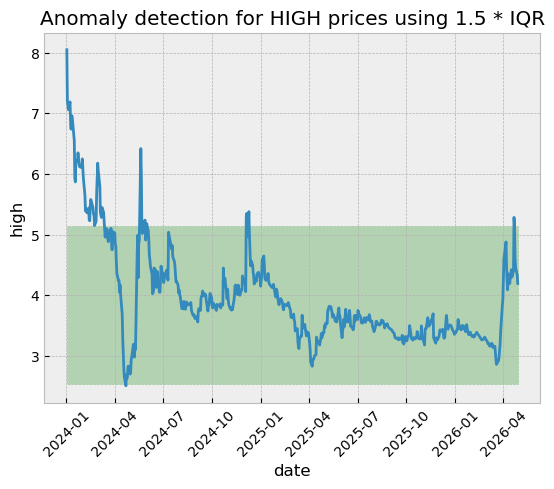

In [270]:
sns.lineplot(x=df.date, y=df.high)
plt.xticks(rotation=45)


# calculating upper and lower using iqr 
iqr = stats.iqr(df.high) 
upper = iqr + np.percentile(df.high, 75) 
lower = np.percentile(df.high, 25) - iqr 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=.25, linestyle='--')

plt.title("Anomaly detection for HIGH prices using 1.5 * IQR")


plt.show()

In [271]:
# anomaly detection using isolation forest

from sklearn.ensemble import IsolationForest

# Prepare the data
high_anomalies = df[['high']].copy()

# Fit Isolation Forest
iso_forest = IsolationForest(
    contamination='auto',  # Expected proportion of anomalies (5%)
    random_state=42,
    n_estimators=100
)

df['anomaly'] = iso_forest.fit_predict(high_anomalies)
df['anomaly_score'] = iso_forest.decision_function(high_anomalies)

# -1 = anomaly, 1 = normal
df['is_anomaly'] = df['anomaly'] == -1

# View anomalies
anomalies = df[df['is_anomaly']][['date', 'high', 'anomaly_score']]
print(f"Found {len(anomalies)} anomalies out of {len(df)} records")
print(anomalies)

Found 152 anomalies out of 582 records
          date   high  anomaly_score
0   2024-01-02  8.050      -0.288611
1   2024-01-03  7.210      -0.226131
2   2024-01-04  7.130      -0.215402
3   2024-01-05  7.060      -0.210578
4   2024-01-08  7.190      -0.223678
..         ...    ...            ...
573 2026-04-16  4.420      -0.000534
576 2026-04-21  5.285      -0.026740
577 2026-04-22  5.120      -0.019841
578 2026-04-23  4.605      -0.043257
579 2026-04-24  4.450      -0.000533

[152 rows x 3 columns]


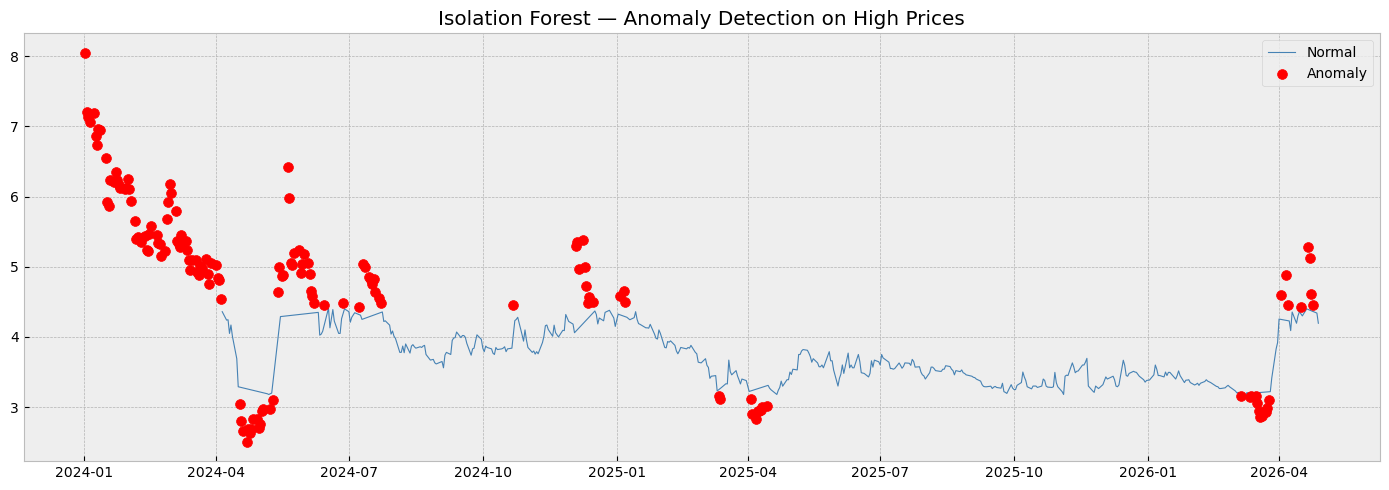

In [272]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

# Normal points
normal = df[~df['is_anomaly']]
ax.plot(normal['date'], normal['high'], color='steelblue', label='Normal', linewidth=0.8)

# Anomalies
ax.scatter(anomalies['date'], anomalies['high'],
           color='red', zorder=5, label='Anomaly', s=50)

ax.set_title('Isolation Forest — Anomaly Detection on High Prices')
ax.legend()
plt.tight_layout()
plt.show()

In [277]:
df.drop(['is_anomaly'],axis=1,inplace=True)


In [57]:
df.head()

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [ ]:
df.drop

In [87]:
# predicting opening price 


# sorting the data by date

df = df.sort_values(['date'],ascending=True)


X = df.drop(['close', 'volume', 'high'],axis=1) 


y = df.high.values.reshape(-1,1) 
# lagging the y
y_lag = np.delete(y, 0)


train_size=round(len(df) * 0.8)
test_size=round(len(df) * 0.2) 



# creating the train/test split 
X_train = X.head(train_size) 
X_test = X.tail(test_size) 

Y_train = y_lag[0:round(len(y_lag) * 0.8)]
Y_test = y_lag[train_size:np.shape(y)[0]]


# fittign the cleaner
clean_iqr_X = clean_iqr(X_train) 

# calculating the column stats
clean_iqr_X.fit()

X_train_transformed = clean_iqr_X.fit_transform()

X_test_transformed = clean_iqr_X.transform(dataframe=X_test)


X_train_transformed = clean_iqr_X.build_lagging(dataframe=X_train_transformed)
X_test_transformed=clean_iqr_X.build_lagging(dataframe=X_test_transformed)


Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: low
Analysing column: adjusted_close
Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: low
Analysing column: adjusted_close
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
Deleting the unecessary columns...
Columns to remove: ['open', 'low', 'adjusted_close']
Transforming... Dataframe
median: [3.74]
upper: [5.3525]
lower: [2.2925]
Transforming... Dataframe
median: [3.665]
upper: [5.15875]
lower: [2.26875]
Transforming... Dataframe
median: [3.74]
upper: [5.375]
lower: [2.255]
Created the lagged values...
dataframe:             day  month  year  open_iqr_imputed  low_iqr_imputed  \
date                                                              
2024-01-02    2      1  2024             3.740            3.665   
2024-01-03    3      1  2024             3.740            3.665   
2024-01-04 

/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:168: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [88]:
X_train_transformed.head()

,day,month,year,lagged_open_iqr_imputed,lagged_low_iqr_imputed,lagged_adjusted_close_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.74,3.665,3.74
2024-01-04,4,1,2024,3.74,3.665,3.74
2024-01-05,5,1,2024,3.74,3.665,3.74
2024-01-08,8,1,2024,3.74,3.665,3.74
2024-01-09,9,1,2024,3.74,3.665,3.74


In [89]:
X_test_transformed.head()

,day,month,year,lagged_open_iqr_imputed,lagged_low_iqr_imputed,lagged_adjusted_close_iqr_imputed
date,,,,,,
2025-12-01,1,12,2025,3.24,3.22,3.24
2025-12-02,2,12,2025,3.21,3.21,3.32
2025-12-03,3,12,2025,3.30,3.30,3.35
2025-12-04,4,12,2025,3.35,3.34,3.36
2025-12-05,5,12,2025,3.32,3.32,3.39


In [90]:
print (np.shape(Y_train))
print (np.shape(X_train_transformed))
print (np.shape(Y_test))
print (np.shape(X_test_transformed))

(478,)
(478, 6)
(119,)
(119, 6)


In [91]:
X_train_transformed.head()

,day,month,year,lagged_open_iqr_imputed,lagged_low_iqr_imputed,lagged_adjusted_close_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.74,3.665,3.74
2024-01-04,4,1,2024,3.74,3.665,3.74
2024-01-05,5,1,2024,3.74,3.665,3.74
2024-01-08,8,1,2024,3.74,3.665,3.74
2024-01-09,9,1,2024,3.74,3.665,3.74


In [92]:
clf = XGBRegressor() 

clf.fit(X_train_transformed, Y_train) 

high_pred = clf.predict(X_test_transformed) 

print (r2_score(y_true=Y_test, y_pred=high_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=high_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=high_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=high_pred)

0.8609677859936042
0.11509463491359678
0.1844755008277934


In [271]:
# attempting skopt bayes search
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer


In [272]:
param_grid = {
    'eta': Real(0.001, 0.5, prior='log-uniform'),
    'tree_method': Categorical(['auto', 'hist', 'exact', 'approx']),
    'max_depth': Integer(6, 50, prior='log-uniform'),
    'num_parallel_tree': Integer(1, 5)
    
}


grid_search = BayesSearchCV(
    estimator=XGBRegressor(n_estimators=30, min_child_weight=0),
    search_spaces=param_grid,
    verbose=3,
    return_train_score=True,
    cv=5,
    scoring='r2',
    n_iter=100,
    n_jobs=-1
)

_ = grid_search.fit(X_train, Y_train) 



Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 4/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.097, test=-7.632) total time=   0.0s
[CV 3/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.098, test=-0.034) total time=   0.0s
[CV 2/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.098, test=-0.168) total time=   0.0s
[CV 5/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.097, test=-28.826) total time=   0.0s
[CV 1/5] END eta=0.0018814045976110847, max_depth=6, num_parallel_tree=2, tree_method=hist;, score=(train=0.094, test=-0.742) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 3/5] END eta=0.2247557242929123, max_depth=13, num_parallel_tree=4, tree_method=exact;, score=(train=1.000, test=-0.155) total time=   0.1s
[CV 4/5] END

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.49999999999999994, 6, 5, 'auto'] before, using random point [0.04905579293774474, 6, 2, 'auto']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.897, test=-0.388) total time=   0.0s
[CV 3/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.922, test=0.528) total time=   0.0s
[CV 2/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.925, test=0.546) total time=   0.0s
[CV 4/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.917, test=0.176) total time=   0.0s
[CV 5/5] END eta=0.04905579293774474, max_depth=6, num_parallel_tree=2, tree_method=auto;, score=(train=0.916, test=-3.584) total time=   0.0s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END eta=0.17527333035869191, max_depth=6, num_parallel_tree=5, tree_method=hist;, score=(train=0.993, test=-0.233) total time=   0.1s
[CV 2/5] END eta=0.17527333

In [273]:
grid_pred = grid_search.predict(X_test) 

print (r2_score(y_true=Y_test, y_pred=grid_pred))

print (mean_absolute_error(y_true=Y_test, y_pred=grid_pred))


print (root_mean_squared_error(y_true=Y_test, y_pred=grid_pred))

clf_mae = mean_absolute_error(y_true=Y_test, y_pred=grid_pred)


0.8065729766878179
0.10499565827742866
0.20211776253684627


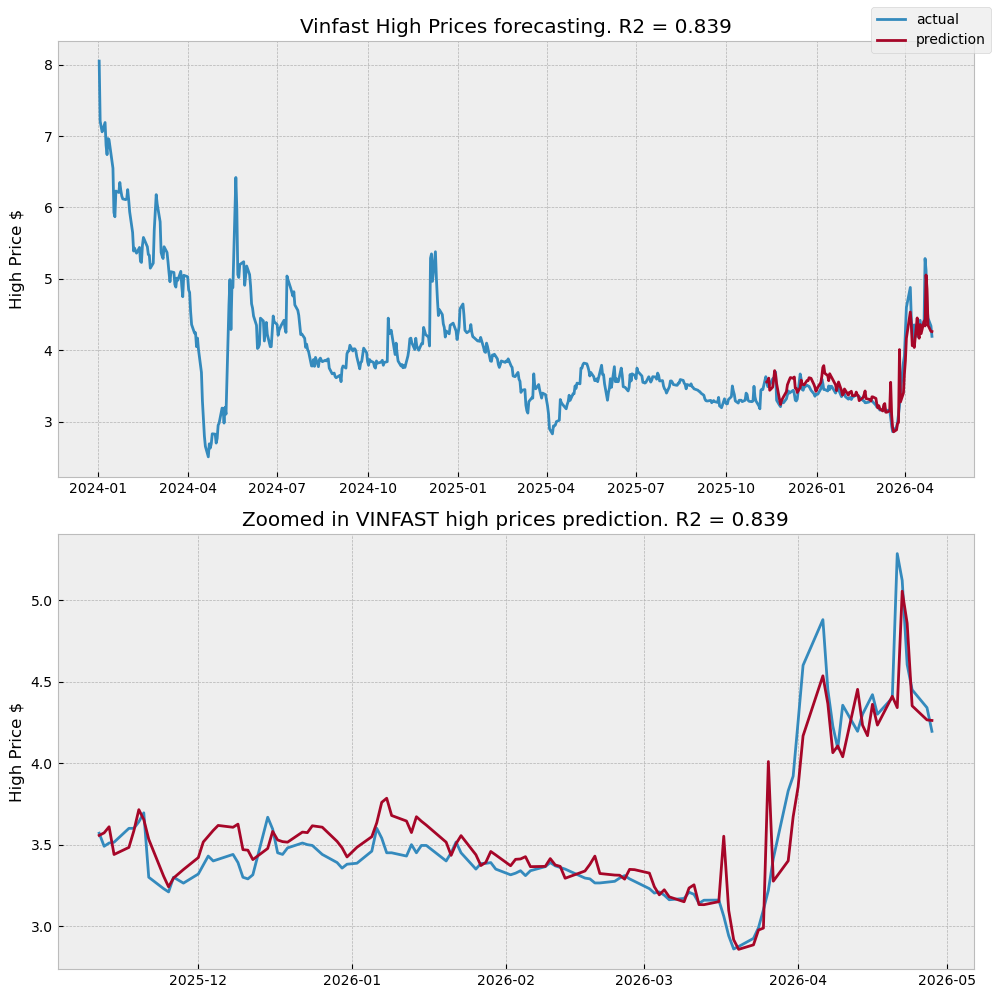

In [297]:
# plotting the lagged high 

# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.high)
axes[0].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[0].set_title(f"Vinfast High Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[0].set_ylabel("High Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], high_pred)



axes[1].set_title(f"Zoomed in VINFAST high prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=high_pred), 3)}")
axes[1].set_ylabel("High Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()



Text(0, 0.5, 'high pred')

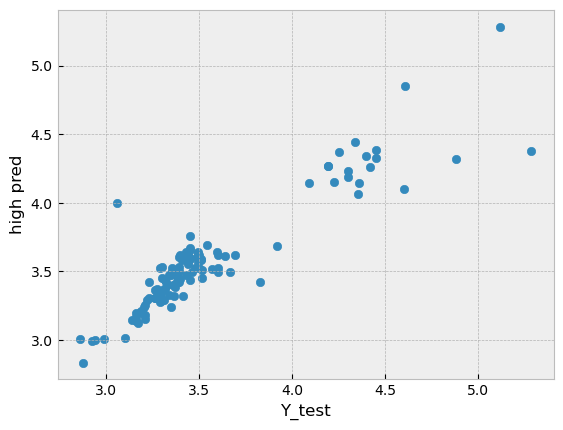

In [276]:
plt.scatter(Y_test, high_pred) 

plt.xlabel("Y_test") 
plt.ylabel("high pred")

In [298]:
X_train_transformed.columns

Index(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='object')

In [278]:
X_train.columns

Index(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_open',
       'lagged_low'],
      dtype='object')

In [299]:
# test prediction 

test_data1 = pd.DataFrame({
    'day': [5],
    'month':[5],
    'year':[2026],
    'lagged_open_iqr_imputed': [4.22],
    'lagged_low_iqr_imputed': [4.16],
    'lagged_adjusted_close_iqr_imputed': [4.21]
    



    



})
# cleaning 

print (test_data1)

test_data1_cleaned = column_cleaner(test_data1) 
test_data1_cleaned = test_data1_cleaned.clean_columns()



print ("Predicting the high for 5/05/2026")
test2_pred = clf.predict(test_data1_cleaned)
print (f"Prediction: {test2_pred}")
print (f"upper bound: {test2_pred + clf_mae}")
print (f"lower bound: {test2_pred - clf_mae}")


   day  month  year  lagged_open_iqr_imputed  lagged_low_iqr_imputed  \
0    5      5  2026                     4.22                    4.16   

   lagged_adjusted_close_iqr_imputed  
0                               4.21  
   day  month  year  lagged_open_iqr_imputed  lagged_low_iqr_imputed  \
0    5      5  2026                     4.22                    4.16   

   lagged_adjusted_close_iqr_imputed  
0                               4.21  
Predicting the high for 5/05/2026
Prediction: [4.3512125]
upper bound: [4.4706492]
lower bound: [4.2317758]


In [94]:
joblib.dump(clf, '../models/time_series/vinfast/vinfast_high_forecaster.pkl')

['../models/time_series/vinfast/vinfast_high_forecaster.pkl']

In [ ]:
# predicting opening priee 

In [288]:
df.head()

,date,open,high,low,close,adjusted_close,volume,day,month,year,open_imputed,anomaly,anomaly_score,is_anomaly,high_imputed
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200,2,1,2024,3.64,-1,-0.288611,True,3.74
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600,3,1,2024,3.64,-1,-0.226131,True,3.74
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600,4,1,2024,3.64,-1,-0.215402,True,3.74
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900,5,1,2024,3.64,-1,-0.210578,True,3.74
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900,8,1,2024,3.64,-1,-0.223678,True,3.74


In [289]:
df = df[['date', 'open', 'adjusted_close', 'close', 'high', 'low', 'day', 'month', 'year']]

In [290]:
df

,date,open,adjusted_close,close,high,low,day,month,year
0,2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024
1,2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024
2,2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024
3,2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024
4,2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024
...,...,...,...,...,...,...,...,...,...
577,2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026
578,2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026
579,2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026
580,2026-04-27,4.230,4.21,4.21,4.340,4.157,27,4,2026


In [291]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

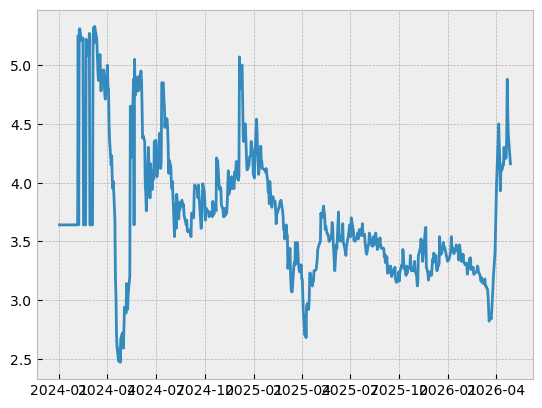

In [422]:
plt.plot(b_transformed.date, b_transformed.open_iqr_imputed)

In [298]:
df

,open,adjusted_close,close,high,low,day,month,year,open_iqr_imputed,adjusted_close_iqr_imputed,close_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,,,,,,,,
2024-01-02,8.040,7.05,7.05,8.050,7.000,2,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-03,7.135,7.08,7.08,7.210,6.835,3,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-04,7.070,7.07,7.07,7.130,6.900,4,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-05,7.000,7.02,7.02,7.060,6.900,5,1,2024,3.64,3.62,3.62,3.740,3.5575
2024-01-08,7.050,6.79,6.79,7.190,6.750,8,1,2024,3.64,3.62,3.62,3.740,3.5575
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,4.880,4.69,4.69,5.120,4.580,22,4,2026,4.88,4.69,4.69,5.120,4.5800
2026-04-23,4.570,4.41,4.41,4.605,4.140,23,4,2026,4.57,4.41,4.41,4.605,4.1400
2026-04-24,4.410,4.36,4.36,4.450,4.335,24,4,2026,4.41,4.36,4.36,4.450,4.3350


In [502]:
df.head()

,date,open,high,low,close,adjusted_close,volume
583,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
584,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
585,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
586,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
587,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


# Creating a model for lower

In [299]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

          date   open   high    low  close  adjusted_close   volume
0   2024-01-02  8.040  8.050  7.000   7.05            7.05  6666200
1   2024-01-03  7.135  7.210  6.835   7.08            7.08  4709600
2   2024-01-04  7.070  7.130  6.900   7.07            7.07  3466600
3   2024-01-05  7.000  7.060  6.900   7.02            7.02  1939900
4   2024-01-08  7.050  7.190  6.750   6.79            6.79  3767900
..         ...    ...    ...    ...    ...             ...      ...
577 2026-04-22  4.880  5.120  4.580   4.69            4.69  1409000
578 2026-04-23  4.570  4.605  4.140   4.41            4.41  1333100
579 2026-04-24  4.410  4.450  4.335   4.36            4.36   457200
580 2026-04-27  4.230  4.340  4.157   4.21            4.21   650700
581 2026-04-28  4.160  4.195  4.000   4.06            4.06   834600

[582 rows x 7 columns]


In [ ]:
d

In [96]:
# predicting low price 


# sorting the data by date

df = df.sort_values(['date'],ascending=True)


X = df.drop(['close', 'volume', 'low'],axis=1) 


y = df.low.values.reshape(-1,1) 
# lagging the y
y_lag = np.delete(y, 0)


train_size=round(len(df) * 0.8)
test_size=round(len(df) * 0.2) 



# creating the train/test split 
X_train = X.head(train_size) 
X_test = X.tail(test_size) 

Y_train = y_lag[0:round(len(y_lag) * 0.8)]
Y_test = y_lag[train_size:np.shape(y)[0]]


# fittign the cleaner
clean_iqr_X = clean_iqr(X_train)

clean_iqr_X.fit() 

X_train_transformed = clean_iqr_X.fit_transform()

X_test_transformed = clean_iqr_X.transform(dataframe=X_test)


X_train_transformed = clean_iqr_X.build_lagging(dataframe=X_train_transformed)
X_test_transformed=clean_iqr_X.build_lagging(dataframe=X_test_transformed)

print (X_train_transformed.head()) 
print (X_test_transformed.head())

Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: high
Analysing column: adjusted_close
Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: high
Analysing column: adjusted_close
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
Deleting the unecessary columns...
Columns to remove: ['open', 'high', 'adjusted_close']
Transforming... Dataframe
median: [3.74]
upper: [5.3525]
lower: [2.2925]
Transforming... Dataframe
median: [3.81]
upper: [5.63375]
lower: [2.20375]
Transforming... Dataframe
median: [3.74]
upper: [5.375]
lower: [2.255]
Created the lagged values...
dataframe:             day  month  year  open_iqr_imputed  high_iqr_imputed  \
date                                                               
2024-01-02    2      1  2024             3.740             3.810   
2024-01-03    3      1  2024             3.740             3.810   
2024-

/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:168: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [ ]:
X_test

In [98]:
X_train_transformed.head()

,day,month,year,lagged_open_iqr_imputed,lagged_high_iqr_imputed,lagged_adjusted_close_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.74,3.81,3.74
2024-01-04,4,1,2024,3.74,3.81,3.74
2024-01-05,5,1,2024,3.74,3.81,3.74
2024-01-08,8,1,2024,3.74,3.81,3.74
2024-01-09,9,1,2024,3.74,3.81,3.74


In [99]:
print (np.shape(Y_train))
print (np.shape(X_train_transformed))
print ("----") 
print (np.shape(Y_test)) 
print (np.shape(X_test_transformed))

(478,)
(478, 6)
----
(119,)
(119, 6)


In [100]:
from xgboost import XGBRegressor

In [105]:
low_clf = XGBRegressor() 

low_clf.fit(X_train_transformed, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [106]:
low_pred = low_clf.predict(X_test_transformed)

In [107]:
# metrics 
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error, mean_squared_error


In [108]:
print (f"r2: {r2_score(y_true=Y_test, y_pred=low_pred)}")
print (f"mean ae: {mean_absolute_error(y_true=Y_test, y_pred=low_pred)}")
print (F"median ae: {median_absolute_error(y_true=Y_test, y_pred=low_pred)}")
print (f"rmse: {root_mean_squared_error(y_true=Y_test, y_pred=low_pred)}")
print (f"mse: {mean_squared_error(y_true=Y_test, y_pred=low_pred)}")

r2: 0.9241924603964667
mean ae: 0.07939426284277137
median ae: 0.06191889762878411
rmse: 0.11049153356721875
mse: 0.012208378990035828


In [109]:
import joblib

In [114]:
joblib.dump(low_clf, '../models/time_series/vinfast/vinfast_low_forecaster.pkl')

['../models/time_series/vinfast/vinfast_low_forecaster.pkl']

<Axes: >

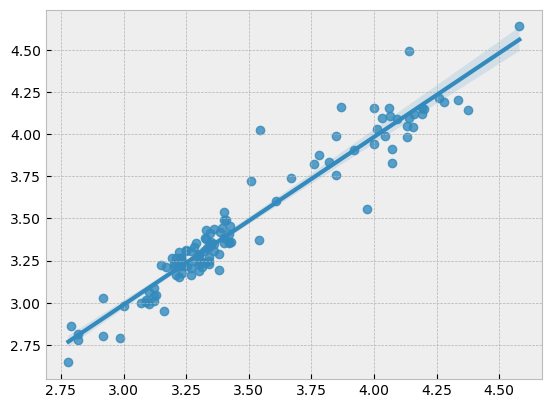

In [111]:
# plotting the results

sns.regplot(x=Y_test, y=low_pred)


# building a model for adjusted close

In [112]:
import joblib 
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

In [113]:
df

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
594,2026-05-14,4.010,4.045,3.782,3.89,3.89,763500
595,2026-05-15,3.820,3.940,3.761,3.83,3.83,568100
596,2026-05-18,3.830,3.865,3.670,3.67,3.67,584000
597,2026-05-19,3.650,3.675,3.510,3.53,3.53,583900


In [340]:
import sys 
sys.path.append("../scripts/")
from clean_time_series import clean_iqr

In [341]:
df.head()

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [115]:
# predicting the adjusted close

X = df[['date', 'open', 'high', 'low']]
y = df.adjusted_close.values.reshape(-1,1) 
TRAIN_SIZE=round(df.shape[0] * 0.8)
TEST_SIZE = round(df.shape[0] * 0.2) 


X_train = X.head(TRAIN_SIZE)
X_test=X.tail(TEST_SIZE)



In [116]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 479 to 598
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    120 non-null    datetime64[ns]
 1   open    120 non-null    float64       
 2   high    120 non-null    float64       
 3   low     120 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.9 KB


In [117]:
Y_train = y[0:TRAIN_SIZE]
Y_test = y[TRAIN_SIZE:len(y)]

Y_train_lag = Y_train[1:]
Y_test_lag = Y_test[1:]

In [118]:
np.shape(Y_test)

(120, 1)

In [119]:
X_train

,date,open,high,low
0,2024-01-02,8.040,8.050,7.000
1,2024-01-03,7.135,7.210,6.835
2,2024-01-04,7.070,7.130,6.900
3,2024-01-05,7.000,7.060,6.900
4,2024-01-08,7.050,7.190,6.750
...,...,...,...,...
474,2025-11-20,3.620,3.695,3.450
475,2025-11-21,3.282,3.300,3.000
476,2025-11-24,3.230,3.230,3.130
477,2025-11-25,3.170,3.210,3.070


In [120]:
clean_iqr_X_train = clean_iqr(X_train)

clean_iqr_X_train.fit() 
X_train_transformed = clean_iqr_X_train.fit_transform()
print ("-----------------------------------")
X_test_transformed = clean_iqr_X_train.transform(dataframe=X_test)


Calculating the upper, lower, median and iqr...
Analysing column: open
Analysing column: high
Analysing column: low
Using the 1.5 * IQR method for anomaly detection...
Analysing column: open
Analysing column: high
Analysing column: low
`day` is a datetime. Ignoring this...
`month` is a datetime. Ignoring this...
`year` is a datetime. Ignoring this...
Deleting the unecessary columns...
Columns to remove: ['open', 'high', 'low']
-----------------------------------
Transforming... Dataframe
median: [3.74]
upper: [5.3525]
lower: [2.2925]
Transforming... Dataframe
median: [3.81]
upper: [5.63375]
lower: [2.20375]
Transforming... Dataframe
median: [3.665]
upper: [5.15875]
lower: [2.26875]


/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(['date'],axis=1,inplace=True)
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['day'] = self.df.index.day
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:168: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [127]:
X_test_transformed

,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,
2025-11-28,28,11,2025,3.24,3.264,3.220
2025-12-01,1,12,2025,3.21,3.320,3.210
2025-12-02,2,12,2025,3.30,3.375,3.300
2025-12-03,3,12,2025,3.35,3.430,3.340
2025-12-04,4,12,2025,3.32,3.400,3.320
...,...,...,...,...,...,...
2026-05-14,14,5,2026,4.01,4.045,3.782
2026-05-15,15,5,2026,3.82,3.940,3.761
2026-05-18,18,5,2026,3.83,3.865,3.670


In [128]:
X_train_transformed

,day,month,year,open_iqr_imputed,high_iqr_imputed,low_iqr_imputed
date,,,,,,
2024-01-02,2,1,2024,3.740,3.810,3.665
2024-01-03,3,1,2024,3.740,3.810,3.665
2024-01-04,4,1,2024,3.740,3.810,3.665
2024-01-05,5,1,2024,3.740,3.810,3.665
2024-01-08,8,1,2024,3.740,3.810,3.665
...,...,...,...,...,...,...
2025-11-20,20,11,2025,3.620,3.695,3.450
2025-11-21,21,11,2025,3.282,3.300,3.000
2025-11-24,24,11,2025,3.230,3.230,3.130


In [129]:
X_train_transformed_lag = clean_iqr_X_train.build_lagging(dataframe=X_train_transformed)
X_test_transformed_lag = clean_iqr_X_train.build_lagging(dataframe=X_test_transformed)

Created the lagged values...
dataframe:             day  month  year  open_iqr_imputed  high_iqr_imputed  \
date                                                               
2024-01-02    2      1  2024             3.740             3.810   
2024-01-03    3      1  2024             3.740             3.810   
2024-01-04    4      1  2024             3.740             3.810   
2024-01-05    5      1  2024             3.740             3.810   
2024-01-08    8      1  2024             3.740             3.810   
...         ...    ...   ...               ...               ...   
2025-11-20   20     11  2025             3.620             3.695   
2025-11-21   21     11  2025             3.282             3.300   
2025-11-24   24     11  2025             3.230             3.230   
2025-11-25   25     11  2025             3.170             3.210   
2025-11-26   26     11  2025             3.200             3.300   

            low_iqr_imputed  lagged_open_iqr_imputed  lagged_high_iqr_imput

/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:288: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[f"lagged_{column}"] = lagged_values
/Users/thomasnguyen/projects/news_project/notebooks/../scripts/clean_time_series.py:288: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [130]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2025-11-28 to 2026-05-20
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   day                      120 non-null    int32  
 1   month                    120 non-null    int32  
 2   year                     120 non-null    int32  
 3   open_iqr_imputed         120 non-null    float64
 4   high_iqr_imputed         120 non-null    float64
 5   low_iqr_imputed          120 non-null    float64
 6   lagged_open_iqr_imputed  120 non-null    float64
 7   lagged_high_iqr_imputed  120 non-null    float64
 8   lagged_low_iqr_imputed   120 non-null    float64
dtypes: float64(6), int32(3)
memory usage: 8.0 KB


In [131]:
X_test_transformed_lag.columns

Index(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_high_iqr_imputed', 'lagged_low_iqr_imputed'],
      dtype='object')

In [132]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, root_mean_squared_error, mean_squared_error

In [133]:
close_clf = XGBRegressor()
close_clf.fit(X_train_transformed_lag, Y_train_lag)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [134]:
close_pred = close_clf.predict(X_test_transformed_lag)

In [135]:
print (f"r2: {r2_score(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mean ae: {mean_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (F"median ae: {median_absolute_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"rmse: {root_mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")
print (f"mse: {mean_squared_error(y_true=Y_test_lag, y_pred=close_pred)}")

r2: 0.8224505793764298
mean ae: 0.12400952715833648
median ae: 0.08768924713134751
rmse: 0.18393082962864948
mse: 0.03383055008788328


In [137]:
joblib.dump(close_clf, '../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl')

['../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl']

In [138]:
X_train_transformed_lag

,day,month,year,lagged_open_iqr_imputed,lagged_high_iqr_imputed,lagged_low_iqr_imputed
date,,,,,,
2024-01-03,3,1,2024,3.740,3.810,3.665
2024-01-04,4,1,2024,3.740,3.810,3.665
2024-01-05,5,1,2024,3.740,3.810,3.665
2024-01-08,8,1,2024,3.740,3.810,3.665
2024-01-09,9,1,2024,3.740,3.810,3.665
...,...,...,...,...,...,...
2025-11-20,20,11,2025,3.590,3.640,3.510
2025-11-21,21,11,2025,3.620,3.695,3.450
2025-11-24,24,11,2025,3.282,3.300,3.000


# predicting for 07/05/2026

In [383]:
import sys 
sys.path.append("../scripts/") 
from clean_time_series import clean_iqr 
from clean_vinfast_stock import column_cleaner
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np


In [416]:
# importing the models
open_clf = joblib.load("../models/time_series/vinfast/vinfast_open_forecaster.pkl") 
high_clf = joblib.load("../models/time_series/vinfast/vinfast_high_forecaster.pkl") 
low_clf = joblib.load("../models/time_series/vinfast/vinfast_low_forecaster.pkl") 
close_clf = joblib.load("../models/time_series/vinfast/vinfast_adjusted_close_forecaster.pkl")


In [417]:
open_clf.feature_names_in_

array(['day', 'month', 'year', 'lagged_adjusted_close', 'lagged_high',
       'lagged_low'], dtype='<U21')

In [413]:
high_clf.feature_names_in_ 


array(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_low_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [414]:
low_clf.feature_names_in_ 

array(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_high_iqr_imputed', 'lagged_adjusted_close_iqr_imputed'],
      dtype='<U33')

In [415]:
close_clf.feature_names_in_

array(['day', 'month', 'year', 'lagged_open_iqr_imputed',
       'lagged_high_iqr_imputed', 'lagged_low_iqr_imputed'], dtype='<U23')

In [139]:
clean_iqr_X.get_column_stats()

,column,iqr,median,upper,lower
0,open,0.7650,3.74,5.35250,2.29250
1,high,0.8575,3.81,5.63375,2.20375
2,adjusted_close,0.7800,3.74,5.37500,2.25500
